# V16b: Three-Path Spectral Mixing

## What changed from V16

V16 had one mixing path: Wilson fiber (causal EMA across positions) + Parseval filter
(gating across modes). V16b adds two more paths from SPECTRE:

| Path | What it does | Scope | Complexity |
|---|---|---|---|
| **Fiber + Parseval filter** | Causal context accumulation, cross-mode gating | Long-range, causal | O(n) |
| **Position FFT** (new) | rfft across positions → content-adaptive gate → irfft | Global, all positions | O(n log n) |
| **Local conv** (new) | Causal depthwise convolution | Local window | O(n·k) |

The position FFT is SPECTRE's core mechanism: FFT across the sequence dimension
mixes all token information globally. The content-adaptive gate (derived from
sequence mean) selects which temporal frequencies matter.

The local conv captures adjacent-token patterns that both the fiber (exponential decay)
and FFT (global) can miss.

## Prefix-FFT Cache

For efficient generation: instead of recomputing the full FFT at each step,
maintain a running FFT and update incrementally per new token.
O(n_freq · d) per token, same cost as KV cache.

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm.auto import tqdm
import math
import time
import os

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

try:
    from datasets import load_dataset
    print("Loading WikiText-103...")
    ds = load_dataset("wikitext", "wikitext-103-raw-v1")
    train_text = "\n".join(ds["train"]["text"])
    val_text = "\n".join(ds["validation"]["text"])
except ImportError:
    raise ImportError("pip install datasets")

try:
    import tiktoken
    enc = tiktoken.get_encoding("gpt2")
    vocab_size = enc.n_vocab
except ImportError:
    from transformers import GPT2TokenizerFast
    enc = GPT2TokenizerFast.from_pretrained("gpt2")
    vocab_size = enc.vocab_size

def tokenize(text):
    if hasattr(enc, 'encode_ordinary'):
        return enc.encode_ordinary(text)
    if hasattr(enc, 'encode'):
        return enc.encode(text)
    return enc(text)['input_ids']

print("Tokenizing...")
train_ids = torch.tensor(tokenize(train_text), dtype=torch.long)
val_ids = torch.tensor(tokenize(val_text), dtype=torch.long)
print(f"Train: {len(train_ids):,} tokens, Val: {len(val_ids):,} tokens, Vocab: {vocab_size:,}")

Device: mps
Loading WikiText-103...
Tokenizing...
Train: 118,496,151 tokens, Val: 248,461 tokens, Vocab: 50,257


In [47]:
@dataclass
class V16bConfig:
    # Spectral structure — same as V16 that hit PPL 275
    n_subbundles: int = 8
    subbundle_dim: int = 32
    n_modes: int = 136
    fiber_dim: int = 256

    # Wilson fiber
    wilson_hidden: int = 256

    # Parseval filter
    filter_hidden: int = 256

    # Causal frequency accumulator
    n_pos_freqs: int = 64            # positional frequency bins to track

    # Local refinement
    local_kernel: int = 7

    # FFN
    ffn_mult: int = 4

    # Model
    n_blocks: int = 7
    vocab_size: int = 50257
    max_seq_len: int = 256
    dropout: float = 0.1

    # Training — same schedule that worked
    learning_rate: float = 1e-4
    min_lr: float = 1e-5
    warmup_steps: int = 1000
    lr_hold_steps: int = 3000
    batch_size: int = 8
    seq_len: int = 256
    max_steps: int = 20000
    eval_interval: int = 500
    eval_steps: int = 10

    @property
    def spectral_half_dim(self):
        return self.subbundle_dim // 2 + 1


cfg = V16bConfig(vocab_size=vocab_size)
print(f"V16b: vocab={cfg.vocab_size:,} seq={cfg.seq_len} batch={cfg.batch_size}")
print(f"Modes: {cfg.n_modes}, Blocks: {cfg.n_blocks}")
print(f"Causal freq bins: {cfg.n_pos_freqs}, Local conv: kernel {cfg.local_kernel}")
print(f"LR: {cfg.learning_rate}, Steps: {cfg.max_steps}")

def get_batch(data, c):
    ix = torch.randint(0, len(data) - c.seq_len - 1, (c.batch_size,))
    return torch.stack([data[i:i+c.seq_len] for i in ix]).to(device)

V16b: vocab=50,257 seq=256 batch=8
Modes: 136, Blocks: 7
Causal freq bins: 64, Local conv: kernel 7
LR: 0.0001, Steps: 20000


## Components

In [48]:
class Constellation:
    """Gaussian cloud constellation: each mode has a center (mag, phase) and spread (log_var).
    The cloud represents uncertainty over spectral identity. Narrow = confident, wide = uncertain.
    Interaction between tokens uses Gaussian overlap, not point inner products."""
    def __init__(self, mag, phase, log_var):
        self.mag = mag          # (B, T, M) center magnitude
        self.phase = phase      # (B, T, M) center phase
        self.log_var = log_var  # (B, T, M) log-variance per mode

    def to_complex(self):
        """Deterministic complex representation (use centers)."""
        return self.mag * torch.exp(1j * self.phase)

    def sample_complex(self):
        """Stochastic: sample mag from Gaussian cloud, keep phase deterministic."""
        std = torch.exp(0.5 * self.log_var)
        sampled_mag = self.mag + std * torch.randn_like(self.mag)
        return sampled_mag * torch.exp(1j * self.phase)

    def to_flat(self):
        return torch.cat([self.mag, self.phase, self.log_var], dim=-1)  # (B, T, 3M)

    def precision(self):
        """Inverse variance = confidence per mode. High precision = narrow cloud."""
        return torch.exp(-self.log_var)

    def overlap(self, other):
        """Gaussian overlap integral between two constellations (per mode).
        Two tokens interact strongly when their clouds overlap significantly.
        Returns (B, T, M) overlap scores."""
        var_sum = torch.exp(self.log_var) + torch.exp(other.log_var)
        diff_sq = (self.mag - other.mag) ** 2
        return torch.exp(-diff_sq / (2 * var_sum)) / var_sum.sqrt()


class CloudNorm(nn.Module):
    """Normalize mag by RMS (like before), leave phase and log_var untouched."""
    def __init__(self, n_modes):
        super().__init__()
        self.mag_scale = nn.Parameter(torch.ones(n_modes))
    def forward(self, c):
        mag_rms = (c.mag ** 2).mean(dim=-1, keepdim=True).sqrt().clamp(min=1e-8)
        return Constellation(c.mag / mag_rms * self.mag_scale, c.phase, c.log_var)


class ConstellationEmbedding(nn.Module):
    """Token → Gaussian cloud constellation.
    mag and phase: separate embeddings (50K × M each).
    log_var: derived from mag via small projection (saves 6.8M params vs separate table)."""
    def __init__(self, cfg):
        super().__init__()
        M = cfg.n_modes
        self.mag_emb = nn.Embedding(cfg.vocab_size, M)
        self.phase_emb = nn.Embedding(cfg.vocab_size, M)
        self.var_proj = nn.Linear(M, M, bias=True)  # 18.6K vs 6.8M
        nn.init.uniform_(self.phase_emb.weight, -math.pi, math.pi)
        nn.init.zeros_(self.var_proj.weight)
        nn.init.zeros_(self.var_proj.bias)  # starts at log_var=0 → variance=1

        freqs = torch.zeros(M)
        for k in range(cfg.n_subbundles):
            off = k * cfg.spectral_half_dim
            freqs[off:off+cfg.spectral_half_dim] = (
                2 * math.pi * torch.fft.rfftfreq(cfg.subbundle_dim, d=1.0))
        self.register_buffer('freqs', freqs)

    def forward(self, token_ids):
        B, T = token_ids.shape
        mag = self.mag_emb(token_ids)
        phase = self.phase_emb(token_ids)
        log_var = self.var_proj(mag)  # derive uncertainty from magnitude
        pos = torch.arange(T, device=token_ids.device).float()
        phase = phase + (pos.unsqueeze(-1) * self.freqs).unsqueeze(0)
        return Constellation(mag, phase, log_var)


class SpatialDecoder(nn.Module):
    """Constellation → spatial via irfft → logits.
    Uses precision-weighted magnitude: confident modes contribute more."""
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.norm = nn.LayerNorm(cfg.fiber_dim)
        self.head = nn.Sequential(
            nn.Linear(cfg.fiber_dim, cfg.fiber_dim),
            nn.SiLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.fiber_dim, cfg.vocab_size),
        )
    def forward(self, constellation):
        # Precision-weight: sharp modes count more in the spatial projection
        precision = constellation.precision()  # (B, T, M)
        weighted_mag = constellation.mag * torch.sigmoid(precision)
        spectral = weighted_mag * torch.exp(1j * constellation.phase)
        shd = self.cfg.spectral_half_dim
        subs = spectral.reshape(*spectral.shape[:-1], self.cfg.n_subbundles, shd)
        spatial = torch.fft.irfft(subs, n=self.cfg.subbundle_dim, dim=-1)
        spatial = spatial.reshape(*spectral.shape[:-1], self.cfg.fiber_dim)
        return self.head(self.norm(spatial))


def complex_parallel_scan(a_re, a_im, b_re, b_im):
    N, T = a_re.shape
    for d in range(int(math.ceil(math.log2(T)))):
        step = 2 ** d
        if step >= T: break
        ar, ai = a_re[:, step:], a_im[:, step:]
        al, ail = a_re[:, :-step], a_im[:, :-step]
        bl, bil = b_re[:, :-step], b_im[:, :-step]
        ab_re = ar * bl - ai * bil
        ab_im = ar * bil + ai * bl
        aa_re = ar * al - ai * ail
        aa_im = ar * ail + ai * al
        b_re = torch.cat([b_re[:, :step], ab_re + b_re[:, step:]], dim=1)
        b_im = torch.cat([b_im[:, :step], ab_im + b_im[:, step:]], dim=1)
        a_re = torch.cat([a_re[:, :step], aa_re], dim=1)
        a_im = torch.cat([a_im[:, :step], aa_im], dim=1)
    return b_re, b_im


def count_params(m):
    return sum(p.numel() for p in m.parameters())

print("Components loaded.")

Components loaded.


## V16b Block: Fiber + Position FFT + Local Conv + FFN

In [49]:
def real_parallel_scan(alpha, x):
    """Real-valued parallel scan for variance accumulation."""
    N, T = alpha.shape
    a, b = alpha, x
    for d in range(int(math.ceil(math.log2(T)))):
        step = 2 ** d
        if step >= T: break
        b = torch.cat([b[:, :step],
                        a[:, step:] * b[:, :-step] + b[:, step:]], dim=1)
        a = torch.cat([a[:, :step],
                        a[:, step:] * a[:, :-step]], dim=1)
    return b


class WilsonFiber(nn.Module):
    """Content-dependent complex EMA that also accumulates variance.
    The fiber state is now a Gaussian: (h_re, h_im, h_var).
    Variance accumulates as: var[t] = decay^2 * var[t-1] + input_var[t].
    This means the accumulated state's uncertainty grows with the number of
    contributors but is tempered by decay (older tokens = less certain)."""
    def __init__(self, cfg):
        super().__init__()
        M = cfg.n_modes
        self.base_decay = nn.Parameter(torch.zeros(M))
        self.wilson_proj = nn.Sequential(
            nn.Linear(3 * M, cfg.wilson_hidden), nn.SiLU(),  # 3M: mag + phase + log_var
            nn.Linear(cfg.wilson_hidden, 2 * M),
        )
        nn.init.zeros_(self.wilson_proj[-1].weight)
        nn.init.zeros_(self.wilson_proj[-1].bias)

    def forward(self, constellation):
        B, T, M = constellation.mag.shape
        flat = constellation.to_flat()  # (B, T, 3M)
        wilson = self.wilson_proj(flat)
        decay = torch.sigmoid(self.base_decay + wilson[..., :M]).clamp(0.01, 0.99)
        theta = torch.tanh(wilson[..., M:]) * math.pi
        z_re = decay * torch.cos(theta)
        z_im = decay * torch.sin(theta)
        c_re = constellation.mag * torch.cos(constellation.phase)
        c_im = constellation.mag * torch.sin(constellation.phase)

        # Complex scan for mean state
        z_re_f = z_re.permute(0,2,1).reshape(B*M, T)
        z_im_f = z_im.permute(0,2,1).reshape(B*M, T)
        c_re_f = c_re.permute(0,2,1).reshape(B*M, T)
        c_im_f = c_im.permute(0,2,1).reshape(B*M, T)
        h_re_f, h_im_f = complex_parallel_scan(z_re_f, z_im_f, c_re_f, c_im_f)
        h_re_f = F.pad(h_re_f[:, :-1], (1, 0))
        h_im_f = F.pad(h_im_f[:, :-1], (1, 0))
        h_re = h_re_f.reshape(B, M, T).permute(0, 2, 1)
        h_im = h_im_f.reshape(B, M, T).permute(0, 2, 1)

        # Variance scan: var[t] = decay^2 * var[t-1] + exp(log_var[t])
        # This is a real EMA with alpha = decay^2
        input_var = torch.exp(constellation.log_var)  # (B, T, M)
        decay_sq = (decay ** 2).permute(0,2,1).reshape(B*M, T) if decay.dim() == 3 else (decay**2).unsqueeze(0).expand(B,-1).reshape(B*M, 1).expand(-1, T)
        # decay is (B, T, M), so decay^2 is also (B, T, M)
        decay_sq_f = (decay ** 2).permute(0,2,1).reshape(B*M, T)
        var_f = input_var.permute(0,2,1).reshape(B*M, T)
        h_var_f = real_parallel_scan(decay_sq_f, var_f)
        h_var_f = F.pad(h_var_f[:, :-1], (1, 0))
        h_var = h_var_f.reshape(B, M, T).permute(0, 2, 1)  # (B, T, M)

        return h_re, h_im, h_var


class ParsevalFilter(nn.Module):
    """Precision-weighted spectral filter with cross-mode interaction.
    The filter gate now takes (mag, phase, log_var) AND the accumulated variance h_var.
    High-precision (low-variance) modes get stronger gating; uncertain modes are attenuated."""
    def __init__(self, cfg):
        super().__init__()
        M = cfg.n_modes
        shd = cfg.spectral_half_dim
        nsub = cfg.n_subbundles
        # Input: 3M (mag, phase, log_var) + M (h_var) = 4M
        self.filter_net = nn.Sequential(
            nn.Linear(4 * M, cfg.filter_hidden), nn.SiLU(),
            nn.Linear(cfg.filter_hidden, 2 * M),
        )
        nn.init.zeros_(self.filter_net[-1].weight)
        nn.init.zeros_(self.filter_net[-1].bias)
        self.cross_re = nn.Parameter(torch.eye(shd).unsqueeze(0).expand(nsub,-1,-1).clone())
        self.cross_im = nn.Parameter(torch.zeros(nsub, shd, shd))
        self.nsub = nsub
        self.shd = shd

    def forward(self, constellation, h_re, h_im, h_var):
        B, T, M = constellation.mag.shape
        # Concatenate constellation flat (3M) + accumulated variance (M)
        inp = torch.cat([constellation.to_flat(), h_var], dim=-1)  # (B, T, 4M)
        raw = self.filter_net(inp)
        w_mag = torch.sigmoid(raw[..., :M])
        w_phase = raw[..., M:]
        w_re = w_mag * torch.cos(w_phase)
        w_im = w_mag * torch.sin(w_phase)
        g_re = (w_re * h_re - w_im * h_im).reshape(B, T, self.nsub, self.shd)
        g_im = (w_re * h_im + w_im * h_re).reshape(B, T, self.nsub, self.shd)
        y_re = (torch.einsum('btsi,sio->btso', g_re, self.cross_re)
              - torch.einsum('btsi,sio->btso', g_im, self.cross_im))
        y_im = (torch.einsum('btsi,sio->btso', g_re, self.cross_im)
              + torch.einsum('btsi,sio->btso', g_im, self.cross_re))
        return y_re.reshape(B, T, M), y_im.reshape(B, T, M)


class PositionFFTMixer(nn.Module):
    """SPECTRE-style: FFT across sequence positions, content-adaptive gate, IFFT back.

    Global descriptor (mean across positions) → MLP → one complex gate per temporal
    frequency bin. Parseval constraint: |gate| ≤ 1.

    The gate is the SAME for all positions (derived from global mean), so the model
    cannot learn position-specific copying. SPECTRE validated this on PG-19.
    Handles variable sequence lengths at generation time."""
    def __init__(self, cfg):
        super().__init__()
        D = cfg.fiber_dim
        n_freq = cfg.seq_len // 2 + 1  # 129 for seq_len=256

        self.gate_net = nn.Sequential(
            nn.Linear(D, cfg.filter_hidden),
            nn.SiLU(),
            nn.Linear(cfg.filter_hidden, 2 * n_freq),
        )
        nn.init.zeros_(self.gate_net[-1].weight)
        nn.init.zeros_(self.gate_net[-1].bias)
        self.n_freq = n_freq
        self.gate_param = nn.Parameter(torch.tensor(-2.0))

    def forward(self, spatial):
        B, T, D = spatial.shape
        n_freq_actual = T // 2 + 1

        q_bar = spatial.mean(dim=1)
        raw = self.gate_net(q_bar)
        gate_mag = torch.sigmoid(raw[:, :min(self.n_freq, n_freq_actual)])
        gate_phase = raw[:, self.n_freq:self.n_freq + min(self.n_freq, n_freq_actual)]

        # Pad or truncate to match actual sequence length
        if n_freq_actual > self.n_freq:
            gate_mag = F.pad(gate_mag, (0, n_freq_actual - self.n_freq), value=0.5)
            gate_phase = F.pad(gate_phase, (0, n_freq_actual - self.n_freq), value=0.0)
        elif n_freq_actual < self.n_freq:
            gate_mag = gate_mag[:, :n_freq_actual]
            gate_phase = gate_phase[:, :n_freq_actual]

        gate = torch.complex(
            gate_mag * torch.cos(gate_phase),
            gate_mag * torch.sin(gate_phase))

        X_hat = torch.fft.rfft(spatial, dim=1)

        # Positional phase injection (SPECTRE 3.3.2d):
        # Multiply each freq bin by exp(j·2π·k·t_avg/N) where t_avg encodes
        # the position. This breaks translation equivariance so the same gate
        # has different effects at different positions, without leaking future info.
        # We use the sequence midpoint as a simple positional anchor.
        k = torch.arange(n_freq_actual, device=spatial.device).float()
        pos_phase = 2 * math.pi * k * (T / 2) / max(T, 1)
        pos_inject = torch.complex(torch.cos(pos_phase), torch.sin(pos_phase))
        gate = gate * pos_inject.unsqueeze(0)  # (B, n_freq) * (1, n_freq)

        X_hat = X_hat * gate.unsqueeze(-1)
        x_out = torch.fft.irfft(X_hat, n=T, dim=1)

        return torch.sigmoid(self.gate_param) * x_out


class LocalRefinement(nn.Module):
    """Causal depthwise convolution for local patterns.
    Captures adjacent-token relationships that fiber (decay) and FFT (global) miss."""
    def __init__(self, cfg):
        super().__init__()
        D = cfg.fiber_dim
        k = cfg.local_kernel
        self.pad = k - 1  # causal: pad only on left
        self.conv = nn.Conv1d(D, D, kernel_size=k, groups=D, bias=True)
        self.gate = nn.Parameter(torch.tensor(-2.0))
        nn.init.zeros_(self.conv.weight)
        nn.init.zeros_(self.conv.bias)

    def forward(self, spatial):
        """spatial: (B, T, D)"""
        h = spatial.transpose(1, 2)  # (B, D, T)
        h = F.pad(h, (self.pad, 0))  # causal padding: left only
        h = self.conv(h)
        h = h.transpose(1, 2)  # (B, T, D)
        return torch.sigmoid(self.gate) * h


class SpatialFFN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D = cfg.fiber_dim
        self.norm = nn.LayerNorm(D)
        self.net = nn.Sequential(
            nn.Linear(D, D * cfg.ffn_mult),
            nn.SiLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(D * cfg.ffn_mult, D),
            nn.Dropout(cfg.dropout),
        )
    def forward(self, spatial):
        return spatial + self.net(self.norm(spatial))


class V16bBlock(nn.Module):
    """Three mixing paths + FFN:
    1. Fiber + Parseval filter → irfft (causal long-range, mode mixing)
    2. Position FFT (global token mixing, SPECTRE-style)
    3. Local conv (causal local patterns)
    4. FFN (per-token nonlinear processing)"""
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        # Normalization
        self.norm = CloudNorm(cfg.n_modes)
        # Path 1: Fiber + Parseval filter
        self.fiber = WilsonFiber(cfg)
        self.pfilter = ParsevalFilter(cfg)
        self.fiber_gate = nn.Parameter(torch.tensor(-2.0))
        # Path 2: Position FFT (SPECTRE-style, global mixing)
        self.pos_fft = PositionFFTMixer(cfg)
        # Path 3: Local conv
        self.local = LocalRefinement(cfg)
        # FFN
        self.ffn = SpatialFFN(cfg)

    def forward(self, constellation):
        B, T, M = constellation.mag.shape
        normed = self.norm(constellation)
        shd = self.cfg.spectral_half_dim
        nsub = self.cfg.n_subbundles
        sdim = self.cfg.subbundle_dim

        # --- Convert normed constellation to spatial (baseline) ---
        c_complex = normed.to_complex()
        c_subs = c_complex.reshape(B, T, nsub, shd)
        current_spatial = torch.fft.irfft(c_subs, n=sdim, dim=-1)
        current_spatial = current_spatial.reshape(B, T, self.cfg.fiber_dim)

        # --- Path 1: Fiber + Parseval filter → irfft ---
        h_re, h_im, h_var = self.fiber(normed)
        y_re, y_im = self.pfilter(normed, h_re, h_im, h_var)
        y_complex = torch.complex(y_re, y_im)
        y_subs = y_complex.reshape(B, T, nsub, shd)
        filtered_spatial = torch.fft.irfft(y_subs, n=sdim, dim=-1)
        filtered_spatial = filtered_spatial.reshape(B, T, self.cfg.fiber_dim)

        # Combine: current spatial + gated fiber context
        spatial = current_spatial + torch.sigmoid(self.fiber_gate) * filtered_spatial

        # --- Path 2: Position FFT (SPECTRE-style global mixing) ---
        spatial = spatial + self.pos_fft(spatial)

        # --- Path 3: Local conv (local patterns) ---
        spatial = spatial + self.local(spatial)

        # --- FFN ---
        spatial = self.ffn(spatial)

        # --- Back to spectral ---
        spatial_subs = spatial.reshape(B, T, nsub, sdim)
        new_complex = torch.fft.rfft(spatial_subs, dim=-1)
        new_complex = new_complex.reshape(B, T, M)
        new_mag = new_complex.abs()
        new_phase = new_complex.angle()

        # Variance update: shrink toward the fiber's accumulated variance
        # The FFN and mixing refine the mean; the variance tracks confidence
        new_log_var = constellation.log_var - 0.1  # each block slightly increases confidence
        new_log_var = new_log_var.clamp(min=-6, max=2)  # bound: exp(-6)≈0.002 to exp(2)≈7.4

        return Constellation(new_mag, new_phase, new_log_var)


class V16bModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embedding = ConstellationEmbedding(cfg)
        # Learned positional encoding in spatial domain (like GPT's pos_emb)
        self.pos_emb = nn.Embedding(cfg.max_seq_len, cfg.fiber_dim)
        self.blocks = nn.ModuleList([V16bBlock(cfg) for _ in range(cfg.n_blocks)])
        self.decoder = SpatialDecoder(cfg)

    def forward(self, token_ids):
        B, T = token_ids.shape
        c = self.embedding(token_ids)

        # Add learned positional encoding via spatial domain:
        # Convert to spatial, add pos_emb, convert back to spectral
        shd = self.cfg.spectral_half_dim
        nsub = self.cfg.n_subbundles
        sdim = self.cfg.subbundle_dim
        spec = c.to_complex()
        subs = spec.reshape(B, T, nsub, shd)
        spatial = torch.fft.irfft(subs, n=sdim, dim=-1).reshape(B, T, self.cfg.fiber_dim)
        spatial = spatial + self.pos_emb(torch.arange(T, device=token_ids.device))
        new_spec = torch.fft.rfft(spatial.reshape(B, T, nsub, sdim), dim=-1).reshape(B, T, self.cfg.n_modes)
        c = Constellation(new_spec.abs(), new_spec.angle(), c.log_var)

        for block in self.blocks:
            c = block(c)
        logits = self.decoder(c)[:, :-1, :]
        return logits, {}


_b = V16bBlock(cfg)
print(f"V16bBlock: {count_params(_b):,} params")
print(f"  Fiber+Filter: {count_params(_b.fiber)+count_params(_b.pfilter):,}")
print(f"  PositionFFT:  {count_params(_b.pos_fft):,}")
print(f"  LocalConv:    {count_params(_b.local):,}")
print(f"  FFN:          {count_params(_b.ffn):,}")

V16bBlock: 1,049,157 params
  Fiber+Filter: 388,792
  PositionFFT:  132,099
  LocalConv:    2,049
  FFN:          526,080


In [50]:
class GPTNano(nn.Module):
    def __init__(self, vocab_size, n_embd=224, n_head=8, n_layer=12,
                 block_size=256, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList()
        for _ in range(n_layer):
            self.blocks.append(nn.ModuleDict({
                'ln1': nn.LayerNorm(n_embd),
                'attn_qkv': nn.Linear(n_embd, 3 * n_embd),
                'attn_proj': nn.Linear(n_embd, n_embd),
                'ln2': nn.LayerNorm(n_embd),
                'mlp_fc1': nn.Linear(n_embd, 4 * n_embd),
                'mlp_fc2': nn.Linear(4 * n_embd, n_embd),
            }))
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.n_head = n_head
        self.n_embd = n_embd
        self.register_buffer('causal_mask',
            torch.tril(torch.ones(block_size, block_size)).view(1,1,block_size,block_size))
    def forward(self, idx):
        B, T = idx.shape
        x = self.drop(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        hd = self.n_embd // self.n_head
        for blk in self.blocks:
            h = blk['ln1'](x)
            qkv = blk['attn_qkv'](h).reshape(B, T, 3, self.n_head, hd)
            q, k, v = qkv.unbind(2)
            q, k, v = q.transpose(1,2), k.transpose(1,2), v.transpose(1,2)
            att = (q @ k.transpose(-2,-1)) * (hd**-0.5)
            att = att.masked_fill(self.causal_mask[:,:,:T,:T]==0, float('-inf'))
            y = (F.softmax(att, dim=-1) @ v).transpose(1,2).reshape(B, T, self.n_embd)
            x = x + blk['attn_proj'](y)
            x = x + blk['mlp_fc2'](F.gelu(blk['mlp_fc1'](blk['ln2'](x))))
        return self.lm_head(self.ln_f(x))[:, :-1, :], {}


models = {}
models['V16b'] = V16bModel(cfg).to(device)
models['GPT-224d'] = GPTNano(vocab_size=cfg.vocab_size, n_embd=224, n_head=8,
                              n_layer=12, block_size=cfg.seq_len).to(device)

print(f"\n{'Model':<15} {'Total':>10}  {'Blocks':>10}  {'Emb+Dec':>10}")
print('=' * 50)
for name, m in models.items():
    total = count_params(m)
    blk = sum(count_params(b) for b in m.blocks)
    print(f"{name:<15} {total:>10,}  {blk:>10,}  {total-blk:>10,}")


Model                Total      Blocks     Emb+Dec
V16b            34,080,524   7,344,099  26,736,425
GPT-224d        29,833,216   7,260,288  22,572,928


## Training

In [51]:
@torch.no_grad()
def estimate_loss(model, c):
    model.eval()
    results = {}
    for name, sd in [('train', train_ids), ('val', val_ids)]:
        tot_ce, tot_ok, tot_n = 0., 0, 0
        for _ in range(c.eval_steps):
            b = get_batch(sd, c)
            logits, _ = model(b)
            tgt = b[:, 1:]
            ce = F.cross_entropy(logits.reshape(-1, c.vocab_size), tgt.reshape(-1))
            tot_ce += ce.item()
            tot_ok += (logits.argmax(-1) == tgt).sum().item()
            tot_n += tgt.numel()
        n = c.eval_steps
        results[name] = {'ce': tot_ce/n, 'acc': tot_ok/tot_n}
    model.train()
    return results

def train_model(model, c, label='model'):
    opt = torch.optim.AdamW(model.parameters(), lr=c.learning_rate, weight_decay=0.05)
    mr = c.min_lr / c.learning_rate
    he = c.warmup_steps + c.lr_hold_steps
    def lr_fn(s):
        if s < c.warmup_steps: return s / max(1, c.warmup_steps)
        if s < he: return 1.0
        p = (s - he) / max(1, c.max_steps - he)
        return max(mr, 0.5 * (1.0 + math.cos(math.pi * p)))

    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_fn)
    hist = {'step':[], 'train_ce':[], 'val_ce':[], 'train_acc':[], 'val_acc':[],
            'train_bpc':[], 'val_bpc':[], 'step_times':[], 'per_step_loss':[]}
    model.train()
    t0 = time.time()
    smooth_loss = None

    pbar = tqdm(range(c.max_steps + 1), desc=label, unit='step')
    for step in pbar:
        if step % c.eval_interval == 0:
            r = estimate_loss(model, c)
            tr, vl = r['train'], r['val']
            hist['step'].append(step)
            hist['train_ce'].append(tr['ce']); hist['val_ce'].append(vl['ce'])
            hist['train_acc'].append(tr['acc']); hist['val_acc'].append(vl['acc'])
            hist['train_bpc'].append(tr['ce']/math.log(2))
            hist['val_bpc'].append(vl['ce']/math.log(2))
            vl_ppl = math.exp(min(vl['ce'], 20))
            tqdm.write(f"  [{label}] {step:5d} | Val CE:{vl['ce']:.3f} "
                       f"BPC:{vl['ce']/math.log(2):.3f} PPL:{vl_ppl:.1f} Acc:{vl['acc']:.1%}")
        if step >= c.max_steps: break
        st = time.time()
        batch = get_batch(train_ids, c)
        opt.zero_grad()
        logits, _ = model(batch)
        tgt = batch[:, 1:]
        loss = F.cross_entropy(logits.reshape(-1, c.vocab_size), tgt.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        elapsed = time.time() - st
        hist['step_times'].append(elapsed)
        hist['per_step_loss'].append(loss.item())
        if smooth_loss is None: smooth_loss = loss.item()
        else: smooth_loss = 0.95 * smooth_loss + 0.05 * loss.item()
        ppl = math.exp(min(smooth_loss, 20))
        pbar.set_postfix(loss=f"{smooth_loss:.3f}", ppl=f"{ppl:.1f}",
                         bpc=f"{smooth_loss/math.log(2):.2f}",
                         lr=f"{sched.get_last_lr()[0]:.1e}", ms=f"{elapsed*1000:.0f}")

    pbar.close()
    el = time.time() - t0
    ms = np.mean(hist['step_times']) * 1000
    final_ppl = math.exp(min(hist['val_ce'][-1], 20))
    print(f"  {label} DONE: {el/60:.1f}min | BPC:{hist['val_bpc'][-1]:.3f} "
          f"PPL:{final_ppl:.1f} Acc:{hist['val_acc'][-1]:.1%} | {ms:.0f}ms/step")
    hist['avg_step_ms'] = ms; hist['n_params'] = count_params(model)
    return hist

In [52]:
all_hist = {}
for name, model in models.items():
    all_hist[name] = train_model(model, cfg, label=name)

V16b:   0%|          | 0/20001 [00:00<?, ?step/s]

  [V16b]     0 | Val CE:10.869 BPC:15.680 PPL:52509.5 Acc:0.0%
  [V16b]   500 | Val CE:7.878 BPC:11.366 PPL:2638.8 Acc:5.0%
  [V16b]  1000 | Val CE:7.102 BPC:10.246 PPL:1214.3 Acc:14.1%
  [V16b]  1500 | Val CE:6.153 BPC:8.876 PPL:470.0 Acc:29.4%
  [V16b]  2000 | Val CE:5.571 BPC:8.037 PPL:262.6 Acc:36.4%
  [V16b]  2500 | Val CE:5.043 BPC:7.276 PPL:155.0 Acc:41.5%
  [V16b]  3000 | Val CE:4.496 BPC:6.487 PPL:89.7 Acc:44.4%
  [V16b]  3500 | Val CE:3.901 BPC:5.627 PPL:49.4 Acc:48.7%
  [V16b]  4000 | Val CE:3.512 BPC:5.067 PPL:33.5 Acc:51.2%
  [V16b]  4500 | Val CE:3.063 BPC:4.418 PPL:21.4 Acc:56.0%
  [V16b]  5000 | Val CE:2.734 BPC:3.945 PPL:15.4 Acc:58.2%
  [V16b]  5500 | Val CE:2.408 BPC:3.474 PPL:11.1 Acc:61.7%
  [V16b]  6000 | Val CE:2.101 BPC:3.031 PPL:8.2 Acc:65.7%
  [V16b]  6500 | Val CE:1.699 BPC:2.451 PPL:5.5 Acc:70.8%
  [V16b]  7000 | Val CE:1.525 BPC:2.200 PPL:4.6 Acc:72.9%
  [V16b]  7500 | Val CE:1.300 BPC:1.876 PPL:3.7 Acc:76.1%
  [V16b]  8000 | Val CE:1.103 BPC:1.592 PPL:3.0 

GPT-224d:   0%|          | 0/20001 [00:00<?, ?step/s]

  [GPT-224d]     0 | Val CE:10.991 BPC:15.857 PPL:59350.4 Acc:0.0%
  [GPT-224d]   500 | Val CE:8.120 BPC:11.715 PPL:3362.5 Acc:4.1%
  [GPT-224d]  1000 | Val CE:7.081 BPC:10.216 PPL:1189.5 Acc:12.6%
  [GPT-224d]  1500 | Val CE:6.971 BPC:10.057 PPL:1065.2 Acc:12.8%
  [GPT-224d]  2000 | Val CE:6.850 BPC:9.882 PPL:943.5 Acc:13.5%
  [GPT-224d]  2500 | Val CE:6.783 BPC:9.786 PPL:882.9 Acc:13.6%
  [GPT-224d]  3000 | Val CE:6.677 BPC:9.633 PPL:794.0 Acc:14.2%
  [GPT-224d]  3500 | Val CE:6.608 BPC:9.533 PPL:741.0 Acc:14.6%
  [GPT-224d]  4000 | Val CE:6.543 BPC:9.439 PPL:694.0 Acc:15.1%
  [GPT-224d]  4500 | Val CE:6.457 BPC:9.316 PPL:637.3 Acc:15.6%
  [GPT-224d]  5000 | Val CE:6.548 BPC:9.447 PPL:697.9 Acc:15.1%
  [GPT-224d]  5500 | Val CE:6.449 BPC:9.304 PPL:632.2 Acc:15.8%
  [GPT-224d]  6000 | Val CE:6.390 BPC:9.219 PPL:596.0 Acc:16.3%
  [GPT-224d]  6500 | Val CE:6.312 BPC:9.106 PPL:551.0 Acc:17.2%
  [GPT-224d]  7000 | Val CE:6.268 BPC:9.042 PPL:527.2 Acc:17.4%
  [GPT-224d]  7500 | Val CE:6.33

## Results

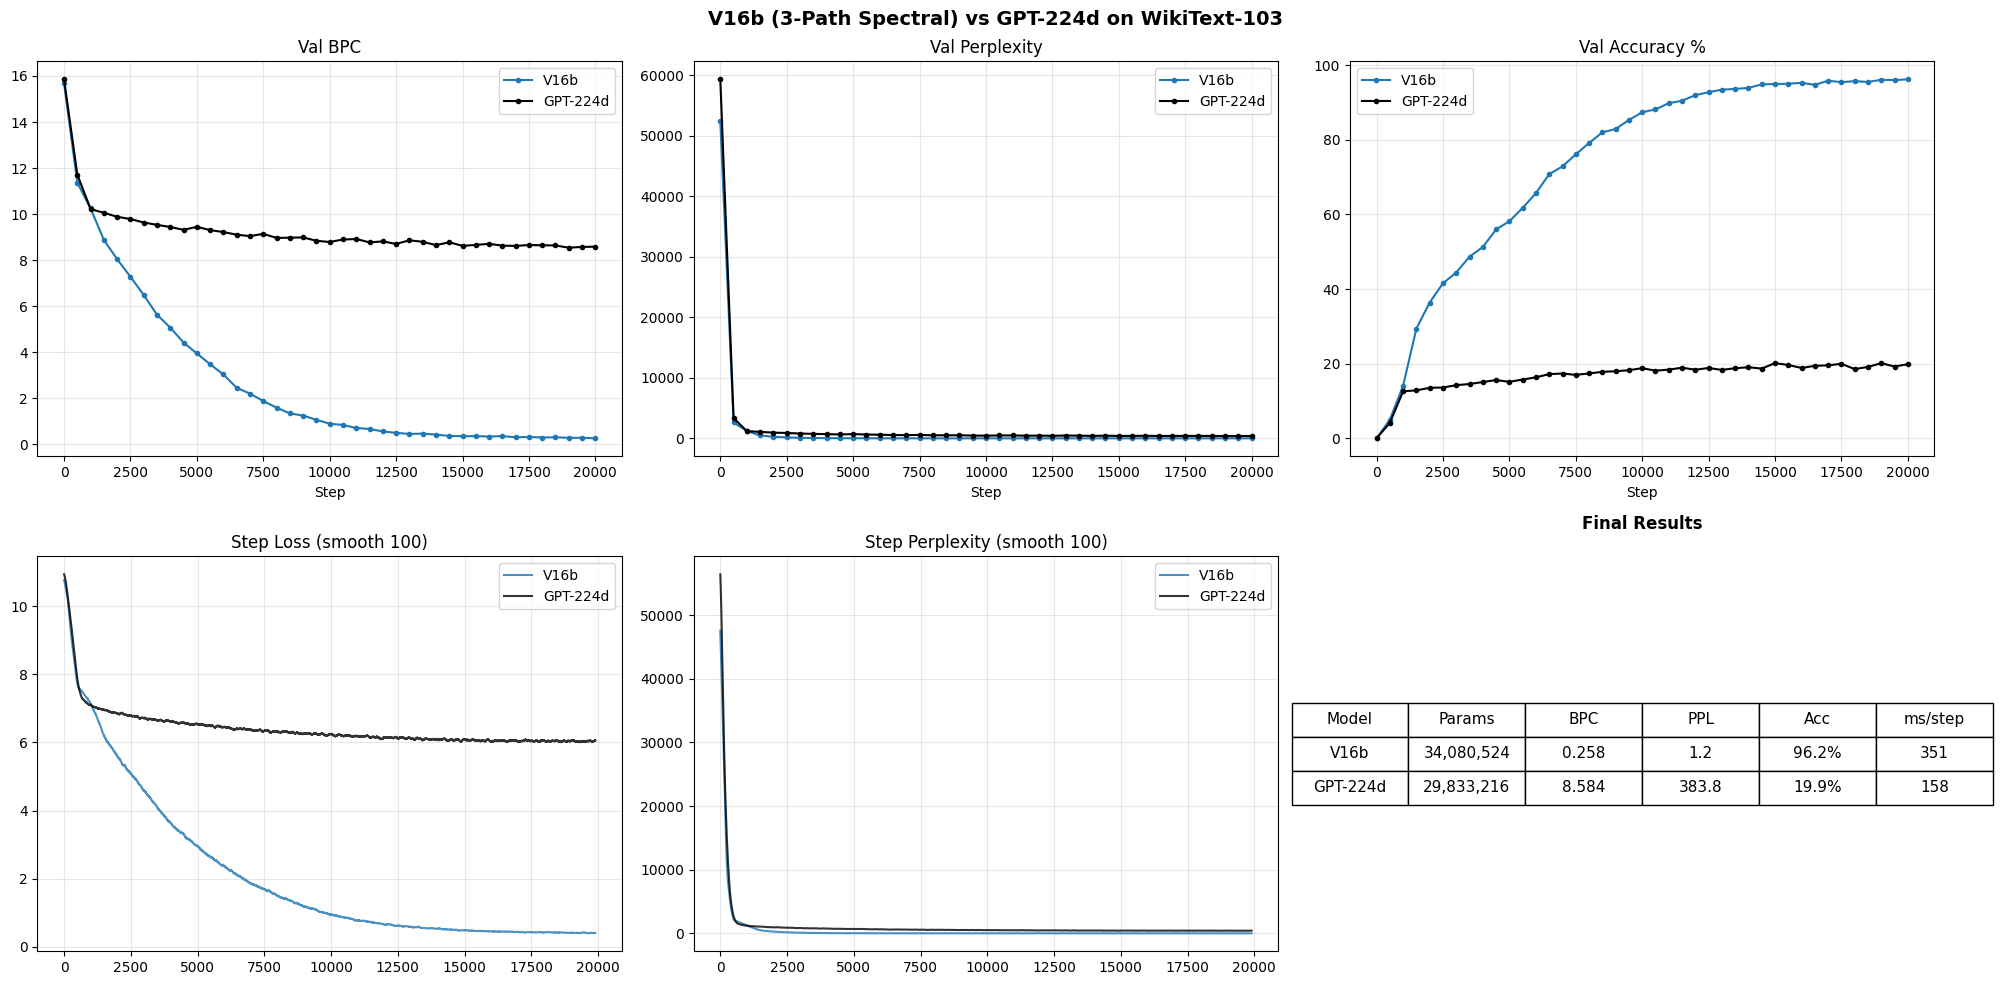


  V16b            BPC:0.258  PPL:1.2  Params:34,080,524  351ms/step
  GPT-224d        BPC:8.584  PPL:383.8  Params:29,833,216  158ms/step


In [53]:
colors = {'V16b': 'tab:blue', 'GPT-224d': 'black'}
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('V16b (3-Path Spectral) vs GPT-224d on WikiText-103', fontsize=14, fontweight='bold')

ax = axes[0, 0]
for name, h in all_hist.items():
    ax.plot(h['step'], h['val_bpc'], '-o', color=colors[name], label=name, markersize=3)
ax.set_xlabel('Step'); ax.set_title('Val BPC'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for name, h in all_hist.items():
    ppl = [math.exp(min(ce, 20)) for ce in h['val_ce']]
    ax.plot(h['step'], ppl, '-o', color=colors[name], label=name, markersize=3)
ax.set_xlabel('Step'); ax.set_title('Val Perplexity'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
for name, h in all_hist.items():
    ax.plot(h['step'], [a*100 for a in h['val_acc']], '-o', color=colors[name],
            label=name, markersize=3)
ax.set_xlabel('Step'); ax.set_title('Val Accuracy %'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
w = 100
for name, h in all_hist.items():
    if len(h['per_step_loss']) > w:
        sm = np.convolve(h['per_step_loss'], np.ones(w)/w, mode='valid')
        ax.plot(range(len(sm)), sm, '-', color=colors[name], label=name, alpha=0.8)
ax.set_title(f'Step Loss (smooth {w})'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for name, h in all_hist.items():
    if len(h['per_step_loss']) > w:
        sm = np.convolve(h['per_step_loss'], np.ones(w)/w, mode='valid')
        ppl_sm = [math.exp(min(x, 20)) for x in sm]
        ax.plot(range(len(ppl_sm)), ppl_sm, '-', color=colors[name], label=name, alpha=0.8)
ax.set_title(f'Step Perplexity (smooth {w})'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 2]; ax.axis('off')
rows = [[name, f"{h['n_params']:,}", f"{h['val_bpc'][-1]:.3f}",
         f"{math.exp(min(h['val_ce'][-1],20)):.1f}",
         f"{h['val_acc'][-1]:.1%}", f"{h['avg_step_ms']:.0f}"]
        for name, h in all_hist.items()]
t = ax.table(cellText=rows, colLabels=['Model','Params','BPC','PPL','Acc','ms/step'],
             loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1.2, 1.8)
ax.set_title('Final Results', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('v16b_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*70)
for name, h in all_hist.items():
    ppl = math.exp(min(h['val_ce'][-1], 20))
    print(f"  {name:<15} BPC:{h['val_bpc'][-1]:.3f}  PPL:{ppl:.1f}  "
          f"Params:{h['n_params']:,}  {h['avg_step_ms']:.0f}ms/step")

## Generation with Prefix-FFT Cache

In [54]:
class PrefixFFTCache:
    """Incremental FFT cache for efficient autoregressive generation.
    Instead of recomputing full FFT at each step, maintains running frequency bins
    and updates them O(n_freq * D) per new token."""
    def __init__(self, n_freq, D, seq_len, device):
        self.freq_cache = torch.zeros(1, n_freq, D, dtype=torch.cfloat, device=device)
        self.seq_len = seq_len
        self.n_freq = n_freq
        self.t = 0
        # Pre-compute twiddle factors
        k = torch.arange(n_freq, device=device).float()
        self.register_k = k  # save for phase computation

    def reset(self):
        self.freq_cache.zero_()
        self.t = 0

    def update(self, x_t):
        """Add new token's spatial representation to the running FFT.
        x_t: (1, D) real-valued spatial features."""
        k = self.register_k
        # Phase for this position: e^(-j*2pi*k*t/N)
        phase = torch.exp(-2j * math.pi * k * self.t / self.seq_len)  # (n_freq,)
        # Update each frequency bin
        self.freq_cache += x_t.unsqueeze(1).to(torch.cfloat) * phase.unsqueeze(0).unsqueeze(-1)
        self.t += 1

    def get_filtered(self, gate_complex):
        """Apply spectral gate and return current position's output.
        gate_complex: (1, n_freq) complex gate values."""
        filtered = gate_complex.unsqueeze(-1) * self.freq_cache
        # IFFT to get full sequence, take last position
        spatial = torch.fft.irfft(filtered, n=self.seq_len, dim=1)  # (1, seq_len, D)
        return spatial[:, self.t - 1, :]  # (1, D) — current position


@torch.no_grad()
def gen(model, prompt_text, c, n=100, temp=0.8):
    """Generate text. Uses full context recomputation (not cached) for simplicity.
    The PrefixFFTCache above shows how to make this O(1) per token."""
    model.eval()
    ids = torch.tensor(tokenize(prompt_text), dtype=torch.long, device=device).unsqueeze(0)
    for _ in range(n):
        ctx = ids[:, -c.seq_len:]
        logits, _ = model(ctx)
        p = F.softmax(logits[:, -1, :] / temp, dim=-1)
        ids = torch.cat([ids, torch.multinomial(p, 1)], dim=1)
    return enc.decode(ids[0].tolist())


for prompt in ['The meaning of life is', 'In the beginning', 'Scientists discovered that']:
    print(f"\nPrompt: {repr(prompt)}")
    for name, model in models.items():
        try:
            text = gen(model, prompt, cfg, n=50)
            print(f"  {name}: {text[len(prompt):len(prompt)+100]}")
        except Exception as e:
            print(f"  {name}: error - {e}")


Prompt: 'The meaning of life is'
  V16b:  life is life is life is life is life is life is life is life is life is life is life is life is lif
  GPT-224d:  for common a " very of racially naturally in . the The C video. of Jasper the andke a in traditiona

Prompt: 'In the beginning'
  V16b:  the beginning the beginning the beginning the beginning the beginning the beginning the beginning t
  GPT-224d:  song of the the University date of . the The Bo carrier review was of a the large series day of of 

Prompt: 'Scientists discovered that'
  V16b:  discovered that discovered that discovered that discovered that discovered that discovered that dis
  GPT-224d:  as is " the a exact real longer " of  the

 All The @ music- ,@ " 300 , m wasalled born displayed f
